# Giorno 2 — Diffie-Hellman, Firme, ECC, PKI e Attacchi

Esercitazione pomeridiana. Percorso:

1. **Diffie-Hellman "live"** tra Alice e Bob.
2. **Man-in-the-Middle su DH**: perché il key exchange da solo non basta → serve autenticazione.
3. **RSA vs ECC**: benchmark quantitativo di dimensioni chiave/firma e velocità.
4. **Firme digitali**: forgery su RSA "nudo" vs hash-and-sign.
5. **Paradosso del compleanno**: collisioni sperimentali su hash troncati.
6. **Side-channel introduttivo**: timing attack su un confronto non a tempo costante.


In [1]:
import os, time, random, hashlib, statistics
from Crypto.PublicKey import ECC, RSA
from Crypto.Signature import DSS, pkcs1_15
from Crypto.Hash import SHA256
from Crypto.Util.number import getPrime, inverse
import matplotlib.pyplot as plt

random.seed(7)
print("Ambiente pronto.")


Ambiente pronto.


## 1. Diffie-Hellman "live"

Implementiamo DH su un gruppo finito con parametri piccoli (solo per la demo). Alice e Bob calcolano
indipendentemente lo stesso segreto condiviso senza mai trasmetterlo.


In [2]:
# Parametri di gruppo pubblici (piccoli, SOLO didattici: in produzione servono gruppi da 2048+ bit
# o curve ellittiche, vedi RFC 3526 / RFC 7919 per gruppi standard)
p = getPrime(256)
g = 2

def dh_keypair():
    priv = random.randrange(2, p - 2)
    pub = pow(g, priv, p)
    return priv, pub

alice_priv, alice_pub = dh_keypair()
bob_priv, bob_pub = dh_keypair()

# Scambio delle sole chiavi pubbliche
alice_shared = pow(bob_pub, alice_priv, p)
bob_shared   = pow(alice_pub, bob_priv, p)

print("Segreto calcolato da Alice == segreto calcolato da Bob:", alice_shared == bob_shared)
print("Il segreto non è mai stato trasmesso in chiaro, solo A_pub e B_pub.")


Segreto calcolato da Alice == segreto calcolato da Bob: True
Il segreto non è mai stato trasmesso in chiaro, solo A_pub e B_pub.


## 2. Man-in-the-Middle: DH senza autenticazione è rotto

Eve si mette in mezzo, intercetta le chiavi pubbliche di Alice e Bob, e sostituisce le proprie. Alice e Bob
credono di condividere un segreto reciproco, ma in realtà condividono un segreto **con Eve**, che può
leggere e ritrasmettere tutto.


In [3]:
eve_priv_A, eve_pub_A = dh_keypair()   # chiave che Eve usa verso Alice
eve_priv_B, eve_pub_B = dh_keypair()   # chiave che Eve usa verso Bob

# Alice crede di parlare con Bob, in realtà riceve la chiave pubblica di Eve
alice_shared_mitm = pow(eve_pub_A, alice_priv, p)
eve_shared_with_alice = pow(alice_pub, eve_priv_A, p)

# Bob crede di parlare con Alice, in realtà riceve l'altra chiave pubblica di Eve
bob_shared_mitm = pow(eve_pub_B, bob_priv, p)
eve_shared_with_bob = pow(bob_pub, eve_priv_B, p)

print("Segreto Alice-Eve coincide (Eve può decifrare tutto ciò che Alice manda):",
      alice_shared_mitm == eve_shared_with_alice)
print("Segreto Bob-Eve coincide (Eve può decifrare tutto ciò che Bob manda):",
      bob_shared_mitm == eve_shared_with_bob)
print("Alice e Bob NON condividono più lo stesso segreto tra loro:",
      alice_shared_mitm != bob_shared_mitm)
print()
print("Eve può decifrare, leggere, e ri-cifrare ogni messaggio inoltrandolo, invisibile a entrambi.")


Segreto Alice-Eve coincide (Eve può decifrare tutto ciò che Alice manda): True
Segreto Bob-Eve coincide (Eve può decifrare tutto ciò che Bob manda): True
Alice e Bob NON condividono più lo stesso segreto tra loro: True

Eve può decifrare, leggere, e ri-cifrare ogni messaggio inoltrandolo, invisibile a entrambi.


**Takeaway**: DH garantisce *secrecy* del segreto scambiato, ma zero **autenticazione** delle chiavi
pubbliche. Da qui nasce il bisogno di certificati, CA e PKI (parte teorica del pomeriggio) e di protocolli
autenticati (es. le firme dentro il TLS handshake).


## 3. RSA vs ECC: quanto costa, a parità di sicurezza?

Confrontiamo RSA-2048/3072 con ECC P-256/P-384 (livelli di sicurezza grosso modo comparabili: 112 e 128
bit rispettivamente) su keygen, firma, verifica, e dimensione della firma.


In [4]:
def bench(fn, repeat=5):
    times = []
    for _ in range(repeat):
        t0 = time.time()
        fn()
        times.append(time.time() - t0)
    return statistics.mean(times)

results = []

for curve, seclevel in [("P-256", "~128 bit"), ("P-384", "~192 bit")]:
    keygen_t = bench(lambda: ECC.generate(curve=curve), repeat=3)
    k = ECC.generate(curve=curve)
    h = SHA256.new(b"messaggio di test")
    signer = DSS.new(k, 'fips-186-3')
    sign_t = bench(lambda: signer.sign(SHA256.new(b"messaggio di test")))
    sig = signer.sign(h)
    verifier = DSS.new(k, 'fips-186-3')
    verify_t = bench(lambda: verifier.verify(SHA256.new(b"messaggio di test"), sig))
    results.append(("ECDSA " + curve, seclevel, keygen_t, sign_t, verify_t, len(sig)))

for bits, seclevel in [(2048, "~112 bit"), (3072, "~128 bit")]:
    keygen_t = bench(lambda: RSA.generate(bits), repeat=2)
    k = RSA.generate(bits)
    h = SHA256.new(b"messaggio di test")
    sig = pkcs1_15.new(k).sign(h)
    sign_t = bench(lambda: pkcs1_15.new(k).sign(SHA256.new(b"messaggio di test")))
    verify_t = bench(lambda: pkcs1_15.new(k.publickey()).verify(SHA256.new(b"messaggio di test"), sig))
    results.append((f"RSA-{bits}", seclevel, keygen_t, sign_t, verify_t, len(sig)))

print(f"{'Schema':<14}{'Sicurezza':<10}{'Keygen(s)':<12}{'Sign(s)':<12}{'Verify(s)':<12}{'FirmaBytes':<10}")
for r in results:
    print(f"{r[0]:<14}{r[1]:<10}{r[2]:<12.4f}{r[3]:<12.5f}{r[4]:<12.5f}{r[5]:<10}")


Schema        Sicurezza Keygen(s)   Sign(s)     Verify(s)   FirmaBytes
ECDSA P-256   ~128 bit  0.0038      0.00082     0.00129     64        
ECDSA P-384   ~192 bit  0.0009      0.00112     0.00310     96        
RSA-2048      ~112 bit  0.3056      0.00122     0.00033     256       
RSA-3072      ~128 bit  2.1525      0.00306     0.00052     384       


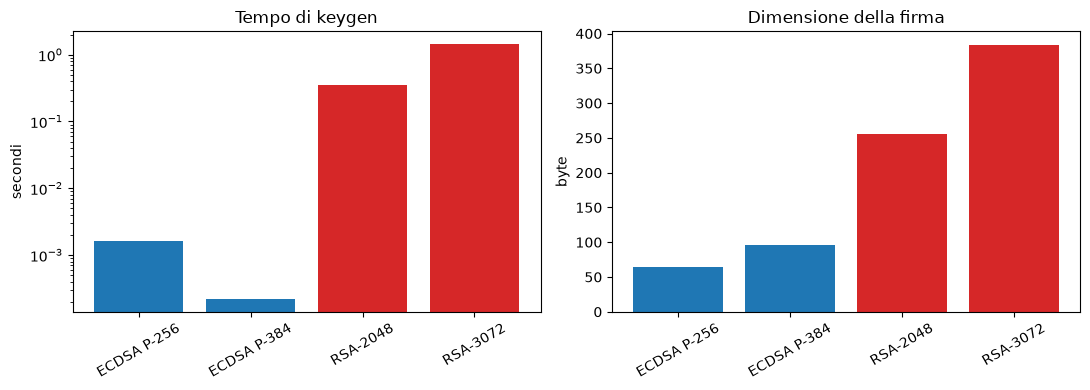

In [6]:
labels = [r[0] for r in results]
keygen_times = [r[2] for r in results]
sig_sizes = [r[5] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].bar(labels, keygen_times, color=['tab:blue','tab:blue','tab:red','tab:red'])
axes[0].set_ylabel("secondi"); axes[0].set_title("Tempo di keygen"); axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(labels, sig_sizes, color=['tab:blue','tab:blue','tab:red','tab:red'])
axes[1].set_ylabel("byte"); axes[1].set_title("Dimensione della firma")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


**Takeaway**: a parità di livello di sicurezza, ECC produce chiavi e firme molto più compatte e keygen
nettamente più veloce di RSA. Questo è il motivo per cui TLS, SSH e i certificati moderni preferiscono ECC
(specialmente su mobile/IoT dove banda e potenza di calcolo sono limitate).


## 4. Firme digitali: forgery su RSA "nudo" vs hash-and-sign

Se si firma **direttamente** un messaggio (interpretato come numero) con RSA, senza prima applicare un
hash, la stessa proprietà moltiplicativa vista il Giorno 1 permette una **forgery esistenziale**: un
attaccante può costruire una firma valida per un messaggio di sua scelta (combinando firme note), senza
mai avere accesso alla chiave privata.


In [ ]:
def rsa_keygen(bits=512, e=65537):
    p = getPrime(bits // 2); q = getPrime(bits // 2)
    n = p * q; phi = (p - 1) * (q - 1)
    d = inverse(e, phi)
    return (n, e), (n, d)

pub, priv = rsa_keygen(512)
n, e = pub; _, d = priv

def sign_raw(m_int):       # firma "nuda": s = m^d mod n
    return pow(m_int, d, n)

def verify_raw(m_int, s):  # verifica: s^e mod n == m ?
    return pow(s, e, n) == m_int

# L'attaccante vuole una firma valida per m_target, senza conoscere d.
m_target = 1000
# Sceglie m1, m2 tali che m1 * m2 == m_target mod n, e si fa firmare LEGITTIMAMENTE m1 e m2
# (es. fingendosi due documenti "innocui" da far firmare al titolare della chiave)
m1 = 10
m2 = m_target  # per semplicità: in un attacco reale si sceglierebbero due fattori non sospetti
# in questo esempio semplificato mostriamo la combinazione s1*s2 corrisponde a m1*m2:
s1 = sign_raw(m1)
s2 = sign_raw(m2)
forged_sig = (s1 * s2) % n
forged_msg = (m1 * m2) % n

print("Firma combinata è valida per il messaggio combinato (mai firmato direttamente):",
      verify_raw(forged_msg, forged_sig))


### Con hash-and-sign l'attacco sparisce
Firmando $H(m)$ invece di $m$, la relazione moltiplicativa tra $m_1, m_2$ e $m_1\cdot m_2$ non si propaga
più alla firma, perché $H(m_1 \cdot m_2) \neq H(m_1)\cdot H(m_2)$ (un hash crittografico non è un
omomorfismo).


In [ ]:
def sign_hashed(m_bytes):
    h = int.from_bytes(hashlib.sha256(m_bytes).digest(), 'big') % n
    return pow(h, d, n)

def verify_hashed(m_bytes, s):
    h = int.from_bytes(hashlib.sha256(m_bytes).digest(), 'big') % n
    return pow(s, e, n) == h

s1h = sign_hashed(b"documento A")
s2h = sign_hashed(b"documento B")
forged_sig_h = (s1h * s2h) % n
# Il "messaggio combinato" non ha più alcun senso semantico e la firma combinata non verifica nulla di utile:
target_bytes = b"documento A" + b"documento B"
print("La stessa strategia di forgery funziona ancora con hash-and-sign?",
      verify_hashed(target_bytes, forged_sig_h))


**Takeaway**: l'hash rompe la struttura algebrica che l'attaccante sfruttava. Questo è anche il motivo
del *paradosso del compleanno* nella prossima sezione: la sicurezza di hash-and-sign contro le forgery
dipende anche dalla resistenza alle collisioni dell'hash.


## 5. Paradosso del compleanno, sperimentale

Cerchiamo collisioni su versioni **troncate** di SHA-256 (pochi bit di output) per rendere l'esperimento
veloce, e confrontiamo il numero di tentativi osservato con la stima teorica $\approx 1.25\sqrt{2^b}$
(dove $b$ = bit di output).


In [ ]:
def truncated_hash(data, bits):
    full = hashlib.sha256(data).digest()
    full_int = int.from_bytes(full, 'big')
    return full_int >> (256 - bits)

def find_collision(bits):
    seen = {}
    attempts = 0
    while True:
        attempts += 1
        msg = os.urandom(8)
        h = truncated_hash(msg, bits)
        if h in seen and seen[h] != msg:
            return attempts, seen[h], msg
        seen[h] = msg

bit_sizes = [16, 18, 20, 22]
observed, theoretical = [], []
for b in bit_sizes:
    trials = [find_collision(b)[0] for _ in range(5)]
    avg_attempts = sum(trials) / len(trials)
    observed.append(avg_attempts)
    theoretical.append(1.25 * (2 ** (b / 2)))
    print(f"{b} bit di output -> media osservata: {avg_attempts:.0f} tentativi, "
          f"stima teorica ~1.25*sqrt(2^{b}) = {theoretical[-1]:.0f}")


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(bit_sizes, observed, marker='o', label="osservato (media 5 run)")
plt.plot(bit_sizes, theoretical, marker='s', linestyle='--', label="stima teorica ~1.25·√(2^b)")
plt.xlabel("bit di output dell'hash troncato")
plt.ylabel("tentativi per trovare una collisione")
plt.yscale('log')
plt.legend(); plt.title("Paradosso del compleanno: collisioni su SHA-256 troncato")
plt.grid(True, alpha=0.3); plt.show()


**Takeaway**: per resistere al paradosso del compleanno con margine di sicurezza $2^k$, l'hash deve
avere **almeno $2k$ bit di output** (non $k$). È il motivo per cui SHA-256 dà "solo" 128 bit di sicurezza
contro le collisioni, pur avendo 256 bit di output.


## 6. Side-channel introduttivo: timing attack su un confronto non a tempo costante

Confrontiamo un confronto byte-per-byte "ingenuo" (che esce al primo mismatch) con uno a tempo costante
(`hmac.compare_digest`), misurando il tempo di esecuzione su tanti tentativi con prefissi via via più
corretti.


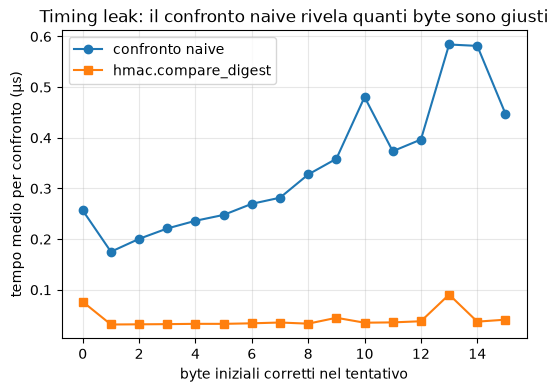

In [8]:
import hmac

SECRET = os.urandom(16)

def naive_compare(a, b):
    if len(a) != len(b):
        return False
    for x, y in zip(a, b):
        if x != y:
            return False
    return True

def timeit_many(fn, a, b, repeat=5000):
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn(a, b)
    return (time.perf_counter() - t0) / repeat

# Costruiamo guess con un numero crescente di byte iniziali corretti
correct_prefix_lengths = list(range(0, 16))
naive_times, constant_times = [], []
for k in correct_prefix_lengths:
    guess = SECRET[:k] + bytes((SECRET[k] + 1) % 256 for _ in [0]) + os.urandom(15 - k) if k < 16 else SECRET
    naive_times.append(timeit_many(naive_compare, SECRET, guess))
    constant_times.append(timeit_many(hmac.compare_digest, SECRET, guess))

plt.figure(figsize=(6,4))
plt.plot(correct_prefix_lengths, [t*1e6 for t in naive_times], marker='o', label="confronto naive")
plt.plot(correct_prefix_lengths, [t*1e6 for t in constant_times], marker='s', label="hmac.compare_digest")
plt.xlabel("byte iniziali corretti nel tentativo")
plt.ylabel("tempo medio per confronto (µs)")
plt.title("Timing leak: il confronto naive rivela quanti byte sono giusti")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


**Takeaway**: nel confronto naive il tempo cresce (anche se di pochissimo per confronto singolo) con il
numero di byte iniziali corretti — un attaccante che può misurare il tempo con precisione e ripetere molte
volte può ricostruire il segreto un byte alla volta, **senza mai romperlo crittograficamente**. Da qui
l'importanza di implementazioni a tempo costante per confronti su segreti (MAC, tag di autenticazione,
padding OAEP/PKCS — collegamento diretto col padding oracle del Giorno 1).
